In [1]:
conda activate omfitenv


Note: you may need to restart the kernel to use updated packages.


In [2]:
from omfit_classes import omfit_eqdsk

In [3]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from uncertainties import ufloat
import numpy as np
from scipy.integrate import cumtrapz
from scipy.constants import mu_0
import os

In [4]:
import matplotlib as mpl

6.787534830468599
7.680631518688152
8.573728206907704


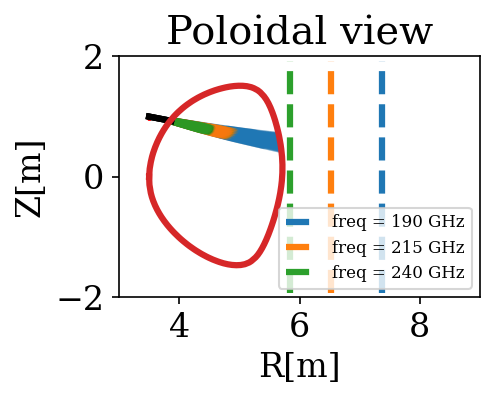

In [5]:
# FILES
#Change this


with plt.rc_context({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "figure.autolayout":True,
    #"legend.frameon" : False,
    "lines.linewidth" : 3.0,
    "lines.markeredgewidth" : 0.0,
    "lines.markersize" : 2.0

}):
    
    fig = plt.figure('fig_offset', figsize=(3.58,5),dpi = 150)
    gs = mpl.gridspec.GridSpec(1,1, figure=fig, width_ratios=[1])
    axs = {}
    axs[1] = fig.add_subplot(gs[0,0])
    #axs[2] = fig.add_subplot(gs[:,1])
    #axs[3] = fig.add_subplot(gs[1,0])
    #axs[4] = fig.add_subplot(gs[1,1])
    
    ax1 = axs[1]
    #ax1cb = axs[2]
    #ax2 = axs[3]


    for sim_index in [0,1,2]:
    
        cwd = os.getcwd()
        SCAN_dir = cwd+'/SCAN'
        sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]
        
        sim = sims[sim_index]
        work_dir = SCAN_dir+'/'+sim+'/work'
        
        eq_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_eq_')]
        #ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
        gfile = work_dir+'/'+eq_dir[0]+'/g000001.00001'
        
        toray_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_ec_')]
        tfile = work_dir+'/'+toray_dir[0]+'/toray.nc'
        
        
        # ORIGINAL TORAY PLOTTING SCRIPT
        #Python
        # originally by Orso
        # modified by Zhixuan 1/7/2015
        import scipy.constants as sc
        
        data = Dataset(tfile)
        #rootgrp = Dataset(ffile)
        geqdsk = omfit_eqdsk.OMFITgeqdsk(gfile)
        
        #n_e = rootgrp['ne'][-1,:]
        
        phi_exp = 0
        alpha = 0.1
        
        # get/calculate physical quantites for rays
        wr = data['wr'][:,:]#[::np.downsamp, ::np.downsamp]
        mask = np.ones(wr.shape)
        mask[np.where(wr == 0)] = np.nan
        mask = mask.T
        
        wphi = data['wphi'][:,:].T * mask
        wr = wr.T * mask / 100.0
        wx = wr * np.cos(wphi + phi_exp)
        wy = wr * np.sin(wphi + phi_exp)
        
        wz = data['wz'][:,:].T * mask / 100.0
        
        x0t = data['x0'][0] / 100.0
        y0t = data['y0'][0] / 100.0
        R0t = np.sqrt(x0t**2 + y0t**2)
        phi0t = np.arctan2(y0t, x0t)
        x0 = R0t * np.cos(phi0t + phi_exp)
        y0 = R0t * np.sin(phi0t + phi_exp)
        
        z0 = data['z0'][0] / 100.0
        x1 = wr[0, 0] * np.cos(wphi[0, 0] + phi_exp)
        y1 = wr[0, 0] * np.sin(wphi[0, 0] + phi_exp)
        
        z1 = data['wz'][:,:].T[0, 0] / 100.0
        
        s = data['delpwr'][:,:].T
        s = s / s[0]
        
        
        Zmax = max(geqdsk['ZLIM'])
        Zmin = min(geqdsk['ZLIM'])
        
        # calculate the resonance field
        m_e = sc.m_e
        m_p = sc.m_p
        q_e = sc.elementary_charge
        eps_0 = sc.epsilon_0
        freq = data['freqcy'][:]
        B_res = freq*2*np.pi*m_e/q_e
        #B_res = freq*2*np.pi*2*m_p/q_e #for Deuterium
        
        # calculate cutoff field
        #N_e = n_e*10**19 #number density of electrons
        #w_pe_squared = N_e*q_e**2/(eps_0*m_e)
        
        #B_cutoff_1 = (m_e/q_e)*(w_pe_squared-(2*np.pi*freq)**2)/(2*np.pi*freq)
        #B_cutoff_2 = (m_e/q_e)*(w_pe_squared-(2*np.pi*freq)**2)/(-2*np.pi*freq)
        
        # accurate resonant surface
        R, Z = np.meshgrid(geqdsk['AuxQuantities']['R'], geqdsk['AuxQuantities']['Z'])
        B = np.sqrt(geqdsk['AuxQuantities']['Bt'] ** 2 + geqdsk['AuxQuantities']['Br'] ** 2 + geqdsk['AuxQuantities']['Bz'] ** 2)
        #plt.contour(R, Z, B, [B_res],colors = 'r') #POLODIAL RESONANT SURFACE
        print(B_res)
        
        # accurate cutoff surface
        #ax1.contour(R, Z ,B, [B_cutoff_2[-1]], colors = 'b')
        #ax1.contour(R, Z ,B, [B_cutoff_2[0]], colors = 'b')
        
        # approximate resonant surface, as the one shown in the toroidal view
        t_angle = np.arange(0, 2 * np.pi, 0.02 * np.pi)
        t_angle = np.append(t_angle, 2 * np.pi)
        R_res = abs(geqdsk['RCENTR'] * geqdsk['BCENTR'] / B_res)
        X_res = R_res * np.cos(t_angle)
        Y_res = R_res * np.sin(t_angle)
        ax1.plot([R_res, R_res], [Zmin, Zmax],linestyle = 'dashed',label = 'freq = {:.0f} GHz'.format(freq/1e9)) #POLODIAL APPROXIMATE RESONANT SURFACE?
        
        
        ax1.scatter(wr, wz, s, alpha=alpha)#, cmap='rainbow') ## POLOIDAL RAYS ##this used plotc, which colors the scatter points with a colorbar
        
        ax1.plot([R0t, wr[0, 0]], [z0, z1], 'k') ##POLOIDAL ANTENNA
    
        
        ax1.scatter(3.5,1,color='r')
        
    
    #geqdsk.plot(only2D=True, color='grey') #POLOIDAL CROSS SECTION
    ax1.plot(geqdsk['RBBBS'], geqdsk['ZBBBS'])
    ax1.set_aspect('equal')
    ax1.set_xlim(3,9)
    ax1.set_ylim(-2,2)
    ax1.set_xlabel('R[m]')
    ax1.set_ylabel('Z[m]')
    
    ax1.set_title('Poloidal view')
    ax1.legend(fontsize = 8)
    plt.show()

In [ ]:
'''
def plot(
        self,
        usePsi=False,
        only1D=False,
        only2D=False,
        top2D=False,
        q_contour_n=0,
        label_contours=False,
        levels=None,
        mask_vessel=True,
        show_limiter=True,
        xlabel_in_legend=False,
        useRhop=False,
        **kw,
    ):
        r"""
        Function used to plot g-files. This plot shows flux surfaces in the vessel, pressure, q profiles, P' and FF'

        :param usePsi: In the plots, use psi instead of rho, or both

        :param only1D: only make plofile plots

        :param only2D: only make flux surface plot

        :param top2D: Plot top-view 2D cross section

        :param q_contour_n: If above 0, plot q contours in 2D plot corresponding to rational surfaces of the given n

        :param label_contours: Adds labels to 2D contours

        :param levels: list of sorted numeric values to pass to 2D plot as contour levels

        :param mask_vessel: mask contours with vessel

        :param show_limiter: Plot the limiter outline in (R,Z) 2D plots

        :param xlabel_in_legend: Show x coordinate in legend instead of under axes (usefull for overplots with psi and rho)

        :param label: plot item label to apply lines in 1D plots (only the q plot has legend called by the geqdsk class
            itself) and to the boundary contour in the 2D plot (this plot doesn't call legend by itself)

        :param ax: Axes instance to plot in when using only2D

        :param \**kw: Standard plot keywords (e.g. color, linewidth) will be passed to Axes.plot() calls.
        """
        import matplotlib

        # backward compatibility: remove deprecated kw (not used anywhere in repo)
        garbage = kw.pop('contour_smooth', None)

        if sum(self['RHOVN']) == 0.0:
            usePsi = True

        def plot2D(what, ax, levels=levels, Z_in=None, **kw):
            if levels is None:
                if what in ['PHIRZ_NORM', 'RHOpRZ', 'RHORZ', 'PSIRZ_NORM']:
                    levels = np.r_[0.1:10:0.1]
                    label_levels = levels[:9]
                elif what in ['QPSIRZ']:
                    q1 = self['QPSI'][-2]  # go one in because edge can be jagged in contour and go outside seperatrix
                    q0 = self['QPSI'][0]
                    qsign = np.sign(q0)  # q profile can be negative depending on helicity
                    levels = np.arange(np.ceil(qsign * q0), np.floor(qsign * q1), 1.0 / int(q_contour_n))[:: int(qsign)] * qsign
                    label_levels = levels
                else:
                    levels = np.linspace(np.nanmin(self['AuxQuantities'][what]), np.nanmax(self['AuxQuantities'][what]), 20)
                    label_levels = levels
            else:
                label_levels = levels

            label = kw.pop('label', None)  # Take this out so the legend doesn't get spammed by repeated labels

            # use this to set up the plot key word args, get the next line color, and move the color cycler along
            (l,) = ax.plot(self['AuxQuantities']['R'], self['AuxQuantities']['R'] * np.nan, **kw)
            # contours
            cs = ax.contour(
                self['AuxQuantities']['R'],
                self['AuxQuantities']['Z'],
                self['AuxQuantities'][what],
                levels,
                colors=[l.get_color()] * len(levels),
                linewidths=l.get_linewidth(),
                alpha=l.get_alpha(),
                linestyles=l.get_linestyle(),
            )

            # optional labeling of contours
            if label_contours:
                label_step = max(len(label_levels) // 4, 1)
                ax.clabel(cs, label_levels[::label_step], inline=True, fontsize=8, fmt='%1.1f')

            # optional masking of contours outside of limiter surface
            if len(self['RLIM']) > 2 and mask_vessel and not np.any(np.isnan(self['RLIM'])) and not np.any(np.isnan(self['ZLIM'])):
                path = matplotlib.path.Path(np.transpose(np.array([self['RLIM'], self['ZLIM']])))
                patch = matplotlib.patches.PathPatch(path, facecolor='none')
                ax.add_patch(patch)
                for col in cs.collections:
                    col.set_clip_path(patch)

            # get the color
            kw1 = copy.copy(kw)
            kw1['linewidth'] = kw['linewidth'] + 1
            kw1.setdefault('color', ax.lines[-1].get_color())

            # boundary
            ax.plot(self['RBBBS'], self['ZBBBS'], label=label, **kw1)

            # magnetic axis
            ax.plot(self['RMAXIS'], self['ZMAXIS'], '+', **kw1)

            # limiter
            if len(self['RLIM']) > 2:
                if show_limiter:
                    ax.plot(self['RLIM'], self['ZLIM'], 'k', linewidth=2)

                try:
                    ax.axis([np.nanmin(self['RLIM']), np.nanmax(self['RLIM']), np.nanmin(self['ZLIM']), np.nanmax(self['ZLIM'])])
                except ValueError:
                    pass

            # aspect_ratio
            ax.set_aspect('equal')
'''

In [68]:
# FFILE DATA
rootgrp = Dataset(ffile)

rho = rootgrp['rho'][:]

te = rootgrp['te'][-1,:]
ti = rootgrp['ti'][-1,:]

prfe = rootgrp['pe_rf'][-1,:]
prfe_int = rootgrp['prfe'][-1]
prfi = rootgrp['pi_rf'][-1,:]
prfi_int = rootgrp['prfi'][-1]

jbs = rootgrp['j_bs'][-1,:]
ibs = rootgrp['ibs'][-1]
jrf = rootgrp['j_rf'][-1,:]
irf = rootgrp['irf'][-1]
jtot = rootgrp['j_tot'][-1,:]




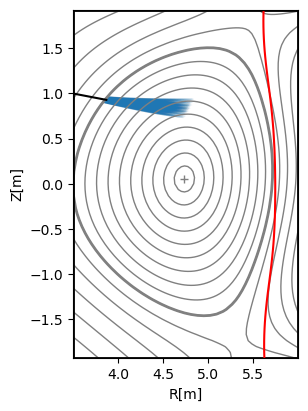

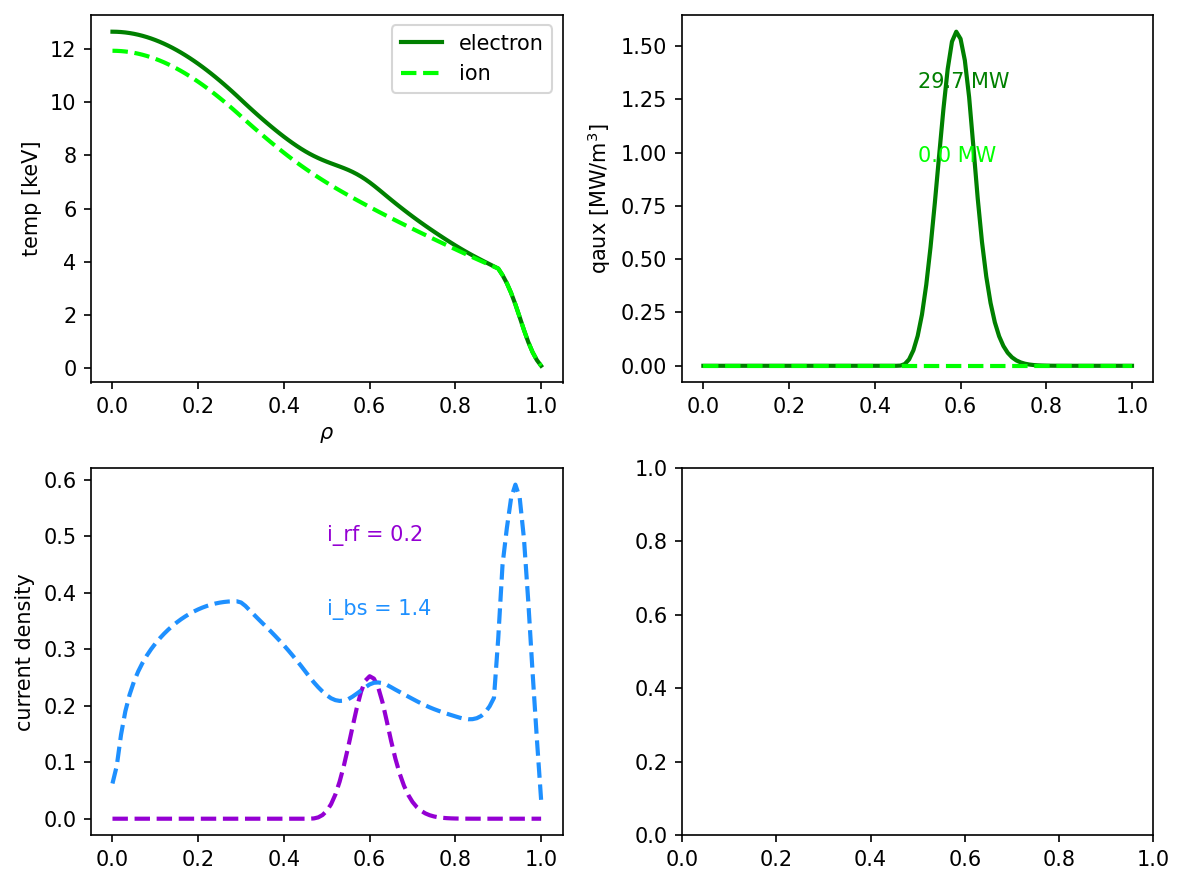

In [69]:
#PLOTS

# Plot poloidal cross section
plt.subplot(1, 2, 2, aspect='equal')
geqdsk.plot(only2D=True, color='grey') #POLOIDAL CROSS SECTION
plt.contour(R, Z, B, [B_res], colors='r') #POLODIAL RESONANT SURFACE
plt.scatter(wr, wz, s, alpha=alpha)#, cmap='rainbow') ## POLOIDAL RAYS ##this used plotc, which colors the scatter points with a colorbar

plt.plot([R0t, wr[0, 0]], [z0, z1], 'k') ##POLOIDAL ANTENNA
plt.xlabel('R[m]')
plt.ylabel('Z[m]')
plt.show()

fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize =(8,6),dpi = 150)
lw = 2
c1 = 'green'
c2 = 'lime'
c3 = 'magenta'
c4 = 'darkviolet'
c5 = 'dodgerblue'
c6 = 'cyan'

# Plot temperature
ax1.plot(rho,te,color = c1,linewidth = lw, label = 'electron')
ax1.plot(rho,ti,color = c2,linewidth = lw,linestyle = 'dashed', label = 'ion')
ax1.set_ylabel('temp [keV]')
ax1.set_xlabel('$\\rho$')
ax1.legend()

# Plot heating
ax2.plot(rho,prfe,color = c1,linewidth = lw)
ax2.plot(rho,prfi,color = c2,linewidth = lw,linestyle = 'dashed')
ax2.set_ylabel('qaux [MW/m$^3$]')
ax2.text(0.5,0.8,'{:.1f} MW'.format(prfe_int),color = c1, transform = ax2.transAxes)
ax2.text(0.5,0.6,'{:.1f} MW'.format(prfi_int),color = c2, transform = ax2.transAxes)

# Plot current
ax3.plot(rho,jrf,color = c4,linewidth = lw,linestyle = 'dashed')
ax3.plot(rho,jbs,color = c5, linewidth =lw, linestyle='dashed')
ax3.text(0.5,0.8,'i_rf = {:.1f}'.format(irf),color = c4,transform = ax3.transAxes)
ax3.text(0.5,0.6,'i_bs = {:.1f}'.format(ibs),color = c5,transform = ax3.transAxes)
ax3.set_ylabel('current density')

fig.tight_layout()
plt.show()

27992489872.33304
